# Compare Pretrained YOLO26n And Retrained Drone Model

This notebook compares two detection models on the same drone-camera test split:

- **Pretrained:** `yolo26n.pt`, trained on general COCO-style images where class `0` is `person`.
- **Retrained:** your custom `best.pt`, trained on `training_yolo26_boxes` where class `0` is `Human`.

The goal is not only to get one metric number. We check:

- official Ultralytics validation metrics (`precision`, `recall`, `mAP50`, `mAP50-95`)
- custom threshold metrics at several confidence thresholds
- missed detections, false positives, and duplicate detections
- visual side-by-side comparisons on representative and failure-case images


## 1. Imports And Configuration

This notebook assumes you already trained the CPU-small model and created `training_yolo26_boxes`. It does not modify the dataset and does not train anything.

In [2]:
from pathlib import Path
from collections import Counter
import random

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from ultralytics import YOLO

ROOT = Path.cwd().resolve()
PROJECT_ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT

DATASET = PROJECT_ROOT / "training_yolo26_boxes"
DATA_YAML = DATASET / "data.yaml"
TEST_IMAGE_DIR = DATASET / "images" / "test"
TEST_LABEL_DIR = DATASET / "labels" / "test"

PRETRAINED_WEIGHTS = PROJECT_ROOT / "notebooks" / "yolo26n.pt"
RETRAINED_WEIGHTS = PROJECT_ROOT / "runs" / "yolo26" / "yolo26n_human_boxes_cpu_small" / "weights" / "best.pt"

# Use the same size as the CPU training run. If your training cell selected 320, change this to 320.
IMG_SIZE = 224
DEVICE = "cpu"
IOU_THRESHOLD = 0.50
CONF_THRESHOLDS = [0.10, 0.25, 0.35, 0.50]
VISUAL_CONF = 0.25
SEED = 42
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}

print("Project root:", PROJECT_ROOT)
print("Dataset:", DATASET)
print("Pretrained weights:", PRETRAINED_WEIGHTS)
print("Retrained weights:", RETRAINED_WEIGHTS)
print("Image size:", IMG_SIZE)

for path in [DATA_YAML, TEST_IMAGE_DIR, TEST_LABEL_DIR, PRETRAINED_WEIGHTS, RETRAINED_WEIGHTS]:
    if not path.exists():
        raise FileNotFoundError(path)


Project root: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model
Dataset: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26_boxes
Pretrained weights: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\notebooks\yolo26n.pt
Retrained weights: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\runs\yolo26\yolo26n_human_boxes_cpu_small\weights\best.pt
Image size: 224


## 2. Load Dataset Metadata

The test split is the only split used for final comparison. It was not used for training or validation during model fitting.

In [3]:
with DATA_YAML.open("r", encoding="utf-8") as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml["names"]
if isinstance(class_names, dict):
    class_names = [class_names[i] for i in sorted(class_names)]

test_images = sorted(p for p in TEST_IMAGE_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTS)
print("Classes:", class_names)
print("Test images:", len(test_images))

def read_yolo_labels(label_path: Path):
    rows = []
    if not label_path.exists():
        return rows
    for line in label_path.read_text(encoding="utf-8").splitlines():
        parts = line.strip().split()
        if len(parts) != 5:
            raise ValueError(f"Expected YOLO box row with 5 columns in {label_path}: {line}")
        class_id = int(float(parts[0]))
        xc, yc, bw, bh = [float(v) for v in parts[1:]]
        rows.append((class_id, xc, yc, bw, bh))
    return rows

object_counts = [len(read_yolo_labels(TEST_LABEL_DIR / f"{p.stem}.txt")) for p in test_images]
print("Test objects:", sum(object_counts))
print("Background images:", sum(1 for n in object_counts if n == 0))


Classes: ['Human']
Test images: 57
Test objects: 79
Background images: 2


## 3. Load Models

Both models are evaluated as one-class human/person detectors. For the pretrained model, class `0` is COCO `person`; for the retrained model, class `0` is your dataset's `Human`.

In [4]:
pretrained_model = YOLO(str(PRETRAINED_WEIGHTS))
retrained_model = YOLO(str(RETRAINED_WEIGHTS))

models = {
    "pretrained_yolo26n": pretrained_model,
    "retrained_best": retrained_model,
}

print("Loaded models:", list(models))


Loaded models: ['pretrained_yolo26n', 'retrained_best']


## 4. Official Ultralytics Metrics

These are the standard detection metrics from Ultralytics. Use these for a quick high-level comparison.

- `precision`: how many predicted humans are actually correct
- `recall`: how many labeled humans are found
- `mAP50`: average precision at IoU 0.50
- `mAP50-95`: stricter localization metric averaged over IoU 0.50 to 0.95


In [8]:
official_rows = []

for model_name, model in models.items():
    print(f"Validating {model_name}...")
    metrics = model.val(
        data=str(DATA_YAML),
        split="test",
        imgsz=IMG_SIZE,
        device=DEVICE,
        workers=0,
        plots=False,
        verbose=False,
    )
    row = {"model": model_name}
    row.update(metrics.results_dict)
    official_rows.append(row)

official_df = pd.DataFrame(official_rows)
official_df


Validating pretrained_yolo26n...
Ultralytics 8.4.56  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core(TM) i7-13700H)
val: Fast image access  (ping: 0.00.0 ms, read: 55.412.6 MB/s, size: 5.0 KB)
val: Scanning C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26_boxes\labels\test.cache... 57 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 57/57  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 4/4 7.2it/s 0.6s0.2s
                   all         57         79      0.741       0.47      0.579      0.383
Speed: 0.1ms preprocess, 6.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Validating retrained_best...
Ultralytics 8.4.56  Python-3.10.20 torch-2.12.0+cpu CPU (13th Gen Intel Core(TM) i7-13700H)
val: Fast image access  (ping: 0.00.0 ms, read: 55.611.9 MB/s, size: 4.8 KB)
val: Scanning C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\training_yolo26_boxes\labels\tes

,model,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),fitness
0,pretrained_yolo26n,0.740651,0.469972,0.579298,0.382743,0.382743
1,retrained_best,0.783074,0.797468,0.847417,0.619063,0.619063


## 5. Custom Threshold Metrics

Official metrics summarize performance across thresholds. For deployment, you still need to choose a confidence threshold. This section evaluates several thresholds using IoU `0.50` matching.

Definitions:

- `TP`: prediction matched to a ground-truth human
- `FP`: prediction not matched to any ground truth
- `FN`: ground-truth human missed by the model
- `duplicates`: extra predictions on already-matched ground-truth boxes


In [6]:
def yolo_box_to_xyxy(row, image_width, image_height):
    _, xc, yc, bw, bh = row
    x1 = (xc - bw / 2) * image_width
    y1 = (yc - bh / 2) * image_height
    x2 = (xc + bw / 2) * image_width
    y2 = (yc + bh / 2) * image_height
    return np.array([x1, y1, x2, y2], dtype=np.float32)

def box_iou_xyxy(a, b):
    x1 = max(a[0], b[0])
    y1 = max(a[1], b[1])
    x2 = min(a[2], b[2])
    y2 = min(a[3], b[3])
    inter = max(0.0, x2 - x1) * max(0.0, y2 - y1)
    area_a = max(0.0, a[2] - a[0]) * max(0.0, a[3] - a[1])
    area_b = max(0.0, b[2] - b[0]) * max(0.0, b[3] - b[1])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0

def image_ground_truth(image_path):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    h, w = image.shape[:2]
    labels = read_yolo_labels(TEST_LABEL_DIR / f"{image_path.stem}.txt")
    boxes = [yolo_box_to_xyxy(row, w, h) for row in labels if row[0] == 0]
    return boxes, w, h

def predict_human_boxes(model, image_path, conf):
    result = model.predict(
        source=str(image_path),
        imgsz=IMG_SIZE,
        conf=conf,
        device=DEVICE,
        verbose=False,
    )[0]
    boxes = []
    if result.boxes is None:
        return boxes
    xyxy = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()
    classes = result.boxes.cls.cpu().numpy().astype(int)
    for box, score, class_id in zip(xyxy, confs, classes):
        if class_id == 0:
            boxes.append({"box": box.astype(np.float32), "conf": float(score), "class_id": int(class_id)})
    boxes.sort(key=lambda item: item["conf"], reverse=True)
    return boxes

def match_predictions(gt_boxes, pred_boxes, iou_threshold):
    matched_gt = set()
    tp = 0
    fp = 0
    duplicates = 0
    best_ious = []

    for pred in pred_boxes:
        if not gt_boxes:
            fp += 1
            continue
        ious = [box_iou_xyxy(pred["box"], gt) for gt in gt_boxes]
        best_idx = int(np.argmax(ious))
        best_iou = float(ious[best_idx])
        if best_iou >= iou_threshold and best_idx not in matched_gt:
            tp += 1
            matched_gt.add(best_idx)
            best_ious.append(best_iou)
        elif best_iou >= iou_threshold and best_idx in matched_gt:
            fp += 1
            duplicates += 1
        else:
            fp += 1

    fn = len(gt_boxes) - len(matched_gt)
    return tp, fp, fn, duplicates, best_ious


In [7]:
threshold_rows = []
per_image_rows = []

for model_name, model in models.items():
    for conf in CONF_THRESHOLDS:
        total_tp = total_fp = total_fn = total_duplicates = 0
        all_ious = []

        for image_path in test_images:
            gt_boxes, _, _ = image_ground_truth(image_path)
            pred_boxes = predict_human_boxes(model, image_path, conf)
            tp, fp, fn, duplicates, ious = match_predictions(gt_boxes, pred_boxes, IOU_THRESHOLD)

            total_tp += tp
            total_fp += fp
            total_fn += fn
            total_duplicates += duplicates
            all_ious.extend(ious)

            per_image_rows.append({
                "model": model_name,
                "conf": conf,
                "image": image_path.name,
                "gt": len(gt_boxes),
                "pred": len(pred_boxes),
                "tp": tp,
                "fp": fp,
                "fn": fn,
                "duplicates": duplicates,
            })

        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) else 0.0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        mean_iou = float(np.mean(all_ious)) if all_ious else 0.0

        threshold_rows.append({
            "model": model_name,
            "conf": conf,
            "tp": total_tp,
            "fp": total_fp,
            "fn": total_fn,
            "duplicates": total_duplicates,
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "mean_matched_iou": mean_iou,
        })

threshold_df = pd.DataFrame(threshold_rows)
per_image_df = pd.DataFrame(per_image_rows)
threshold_df


,model,conf,tp,fp,fn,duplicates,precision,recall,f1,mean_matched_iou
0,pretrained_yolo26n,0.10,43,27,36,13,0.614286,0.544304,0.577181,0.830873
1,pretrained_yolo26n,0.25,34,7,45,1,0.829268,0.430380,0.566667,0.859642
2,pretrained_yolo26n,0.35,27,4,52,0,0.870968,0.341772,0.490909,0.874585
3,pretrained_yolo26n,0.50,26,3,53,0,0.896552,0.329114,0.481481,0.874454
4,retrained_best,0.10,69,46,10,22,0.600000,0.873418,0.711340,0.846720
5,retrained_best,0.25,66,17,13,8,0.795181,0.835443,0.814815,0.851753
6,retrained_best,0.35,61,14,18,6,0.813333,0.772152,0.792208,0.858319
7,retrained_best,0.50,58,6,21,0,0.906250,0.734177,0.811189,0.864872


## 6. Plot Precision, Recall, And F1 By Confidence

Use this to choose a deployment confidence threshold. Lower threshold usually increases recall but may add false positives. Higher threshold usually reduces false positives but misses more people.

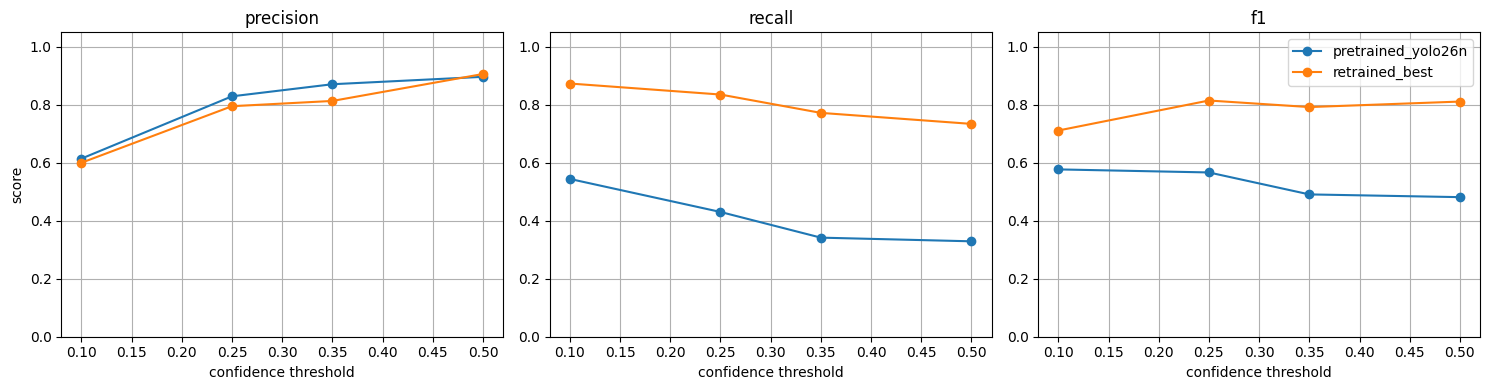

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for metric, ax in zip(["precision", "recall", "f1"], axes):
    for model_name in threshold_df["model"].unique():
        subset = threshold_df[threshold_df["model"] == model_name]
        ax.plot(subset["conf"], subset[metric], marker="o", label=model_name)
    ax.set_title(metric)
    ax.set_xlabel("confidence threshold")
    ax.set_ylim(0, 1.05)
    ax.grid(True)
axes[0].set_ylabel("score")
axes[-1].legend()
plt.tight_layout()


## 7. Visual Helper Functions

These functions draw ground truth and filtered human/person predictions. We draw boxes ourselves so both models use the same colors and class filtering.

In [10]:
def draw_boxes(image_path, gt_boxes=None, pred_boxes=None, title=""):
    image = cv2.imread(str(image_path))
    if image is None:
        raise ValueError(f"Could not read image: {image_path}")
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    if gt_boxes:
        for box in gt_boxes:
            x1, y1, x2, y2 = [int(v) for v in box]
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 220, 255), 2)
            cv2.putText(image, "GT", (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 220, 255), 1)

    if pred_boxes:
        for pred in pred_boxes:
            x1, y1, x2, y2 = [int(v) for v in pred["box"]]
            score = pred["conf"]
            cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
            cv2.putText(image, f"{score:.2f}", (x1, max(y1 - 5, 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 0), 1)

    return image

def image_brightness(image_path):
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    return float(image.mean())

def min_gt_area(image_path):
    gt_boxes, w, h = image_ground_truth(image_path)
    if not gt_boxes:
        return 1.0
    return min(((box[2] - box[0]) * (box[3] - box[1])) / (w * h) for box in gt_boxes)

def unique_keep_order(paths):
    result = []
    seen = set()
    for path in paths:
        if path not in seen:
            result.append(path)
            seen.add(path)
    return result


## 8. Representative Side-By-Side Visuals

Each row shows:

- left: ground truth
- middle: pretrained model predictions
- right: retrained model predictions

This sample intentionally includes dark, bright, small-object, and multi-person cases.

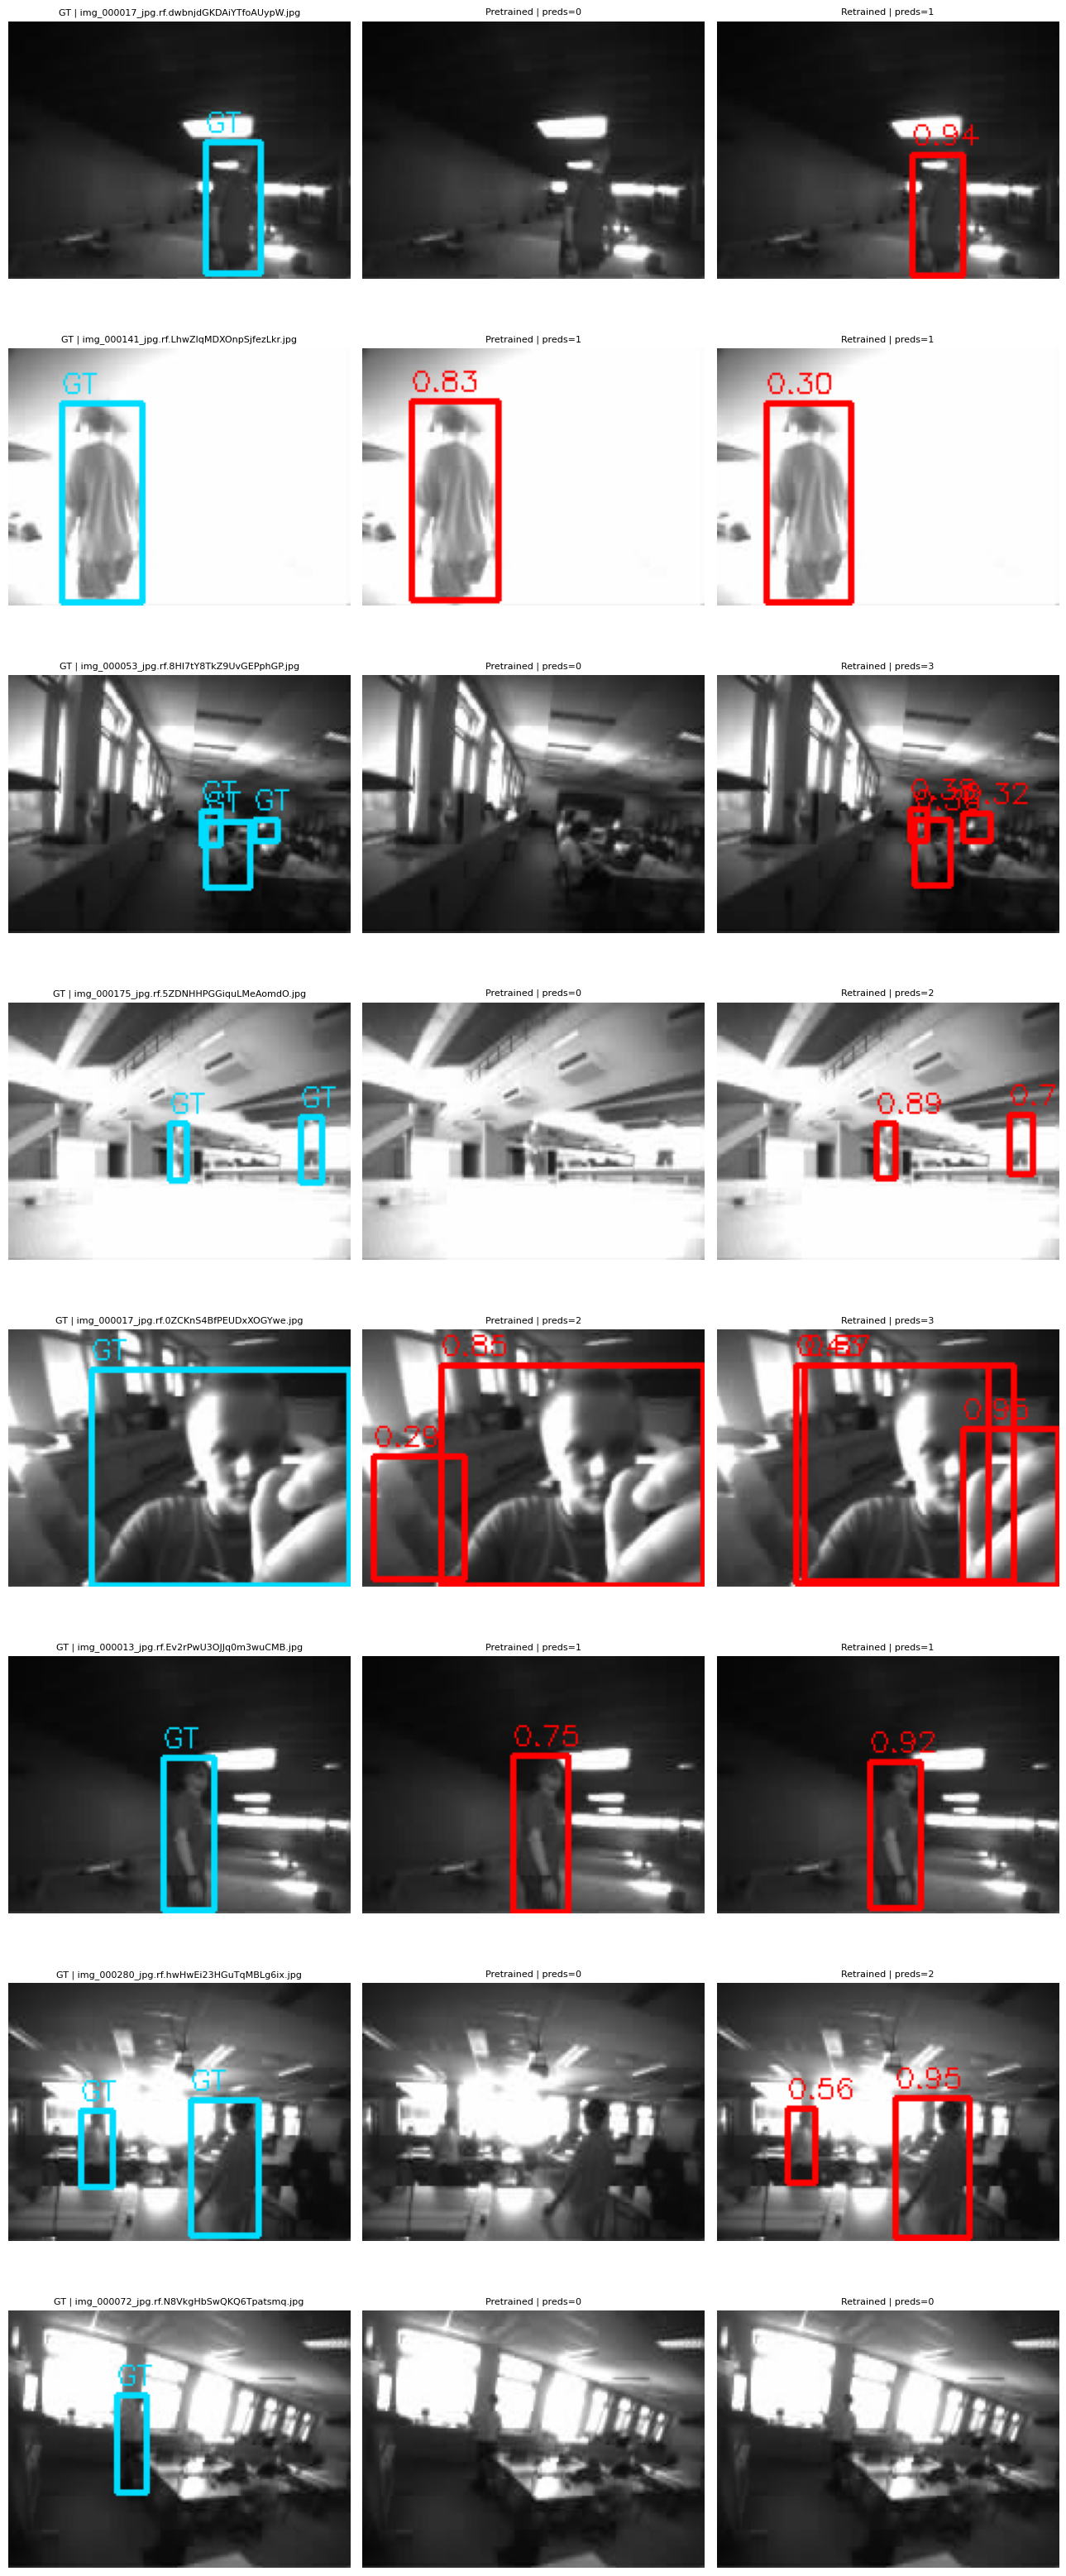

In [11]:
non_empty_images = [p for p in test_images if read_yolo_labels(TEST_LABEL_DIR / f"{p.stem}.txt")]

selected = unique_keep_order([
    min(non_empty_images, key=image_brightness),
    max(non_empty_images, key=image_brightness),
    min(non_empty_images, key=min_gt_area),
    max(non_empty_images, key=lambda p: len(read_yolo_labels(TEST_LABEL_DIR / f"{p.stem}.txt"))),
])

rng = random.Random(SEED)
for path in rng.sample(non_empty_images, k=min(8, len(non_empty_images))):
    selected = unique_keep_order(selected + [path])
    if len(selected) >= 8:
        break

fig, axes = plt.subplots(len(selected), 3, figsize=(13, 4 * len(selected)))
if len(selected) == 1:
    axes = np.array([axes])

for row_axes, image_path in zip(axes, selected):
    gt_boxes, _, _ = image_ground_truth(image_path)
    pre_preds = predict_human_boxes(pretrained_model, image_path, VISUAL_CONF)
    ret_preds = predict_human_boxes(retrained_model, image_path, VISUAL_CONF)

    panels = [
        (draw_boxes(image_path, gt_boxes=gt_boxes), f"GT | {image_path.name}"),
        (draw_boxes(image_path, pred_boxes=pre_preds), f"Pretrained | preds={len(pre_preds)}"),
        (draw_boxes(image_path, pred_boxes=ret_preds), f"Retrained | preds={len(ret_preds)}"),
    ]

    for ax, (image, title) in zip(row_axes, panels):
        ax.imshow(image)
        ax.set_title(title, fontsize=8)
        ax.axis("off")

plt.tight_layout()


## 9. Failure Cases For The Retrained Model

This focuses on images where the retrained model misses humans or creates false positives at `VISUAL_CONF`. These are the examples that should guide the next labeling/training round.

In [12]:
failure_rows = per_image_df[
    (per_image_df["model"] == "retrained_best")
    & (per_image_df["conf"] == VISUAL_CONF)
    & ((per_image_df["fn"] > 0) | (per_image_df["fp"] > 0))
].sort_values(["fn", "fp"], ascending=False)

failure_rows.head(12)


,model,conf,image,gt,pred,tp,fp,fn,duplicates
302,retrained_best,0.25,img_000058_jpg.rf.tOuOAB22F00CwiD0D1vH.jpg,3,3,1,2,2,1
306,retrained_best,0.25,img_000080_jpg.rf.Q6hsP2K4ytOdTXvBUBx8.jpg,3,1,1,0,2,0
336,retrained_best,0.25,img_000302_jpg.rf.TIw3cXudwhMsnPvumTTn.jpg,3,4,2,2,1,2
337,retrained_best,0.25,img_000303_jpg.rf.injjvONGbUvfRSVLN2FQ.jpg,3,4,2,2,1,1
318,retrained_best,0.25,img_000120_jpg.rf.URyy2nFRTEX9TbznZsey.jpg,2,2,1,1,1,0
325,retrained_best,0.25,img_000175_jpg.rf.53mF12NwQJbravuPKSbP.jpg,2,2,1,1,1,0
332,retrained_best,0.25,img_000259_jpg.rf.6QAqIuCPNEzt31XLxi4D.jpg,2,2,1,1,1,0
296,retrained_best,0.25,img_000045_jpg.rf.RwCUecyg6if5uJBlfU17.jpg,2,1,1,0,1,0
303,retrained_best,0.25,img_000072_jpg.rf.N8VkgHbSwQKQ6Tpatsmq.jpg,1,0,0,0,1,0
334,retrained_best,0.25,img_000288_jpg.rf.RvKxFn1DxdPZyeRNwOUA.jpg,1,0,0,0,1,0


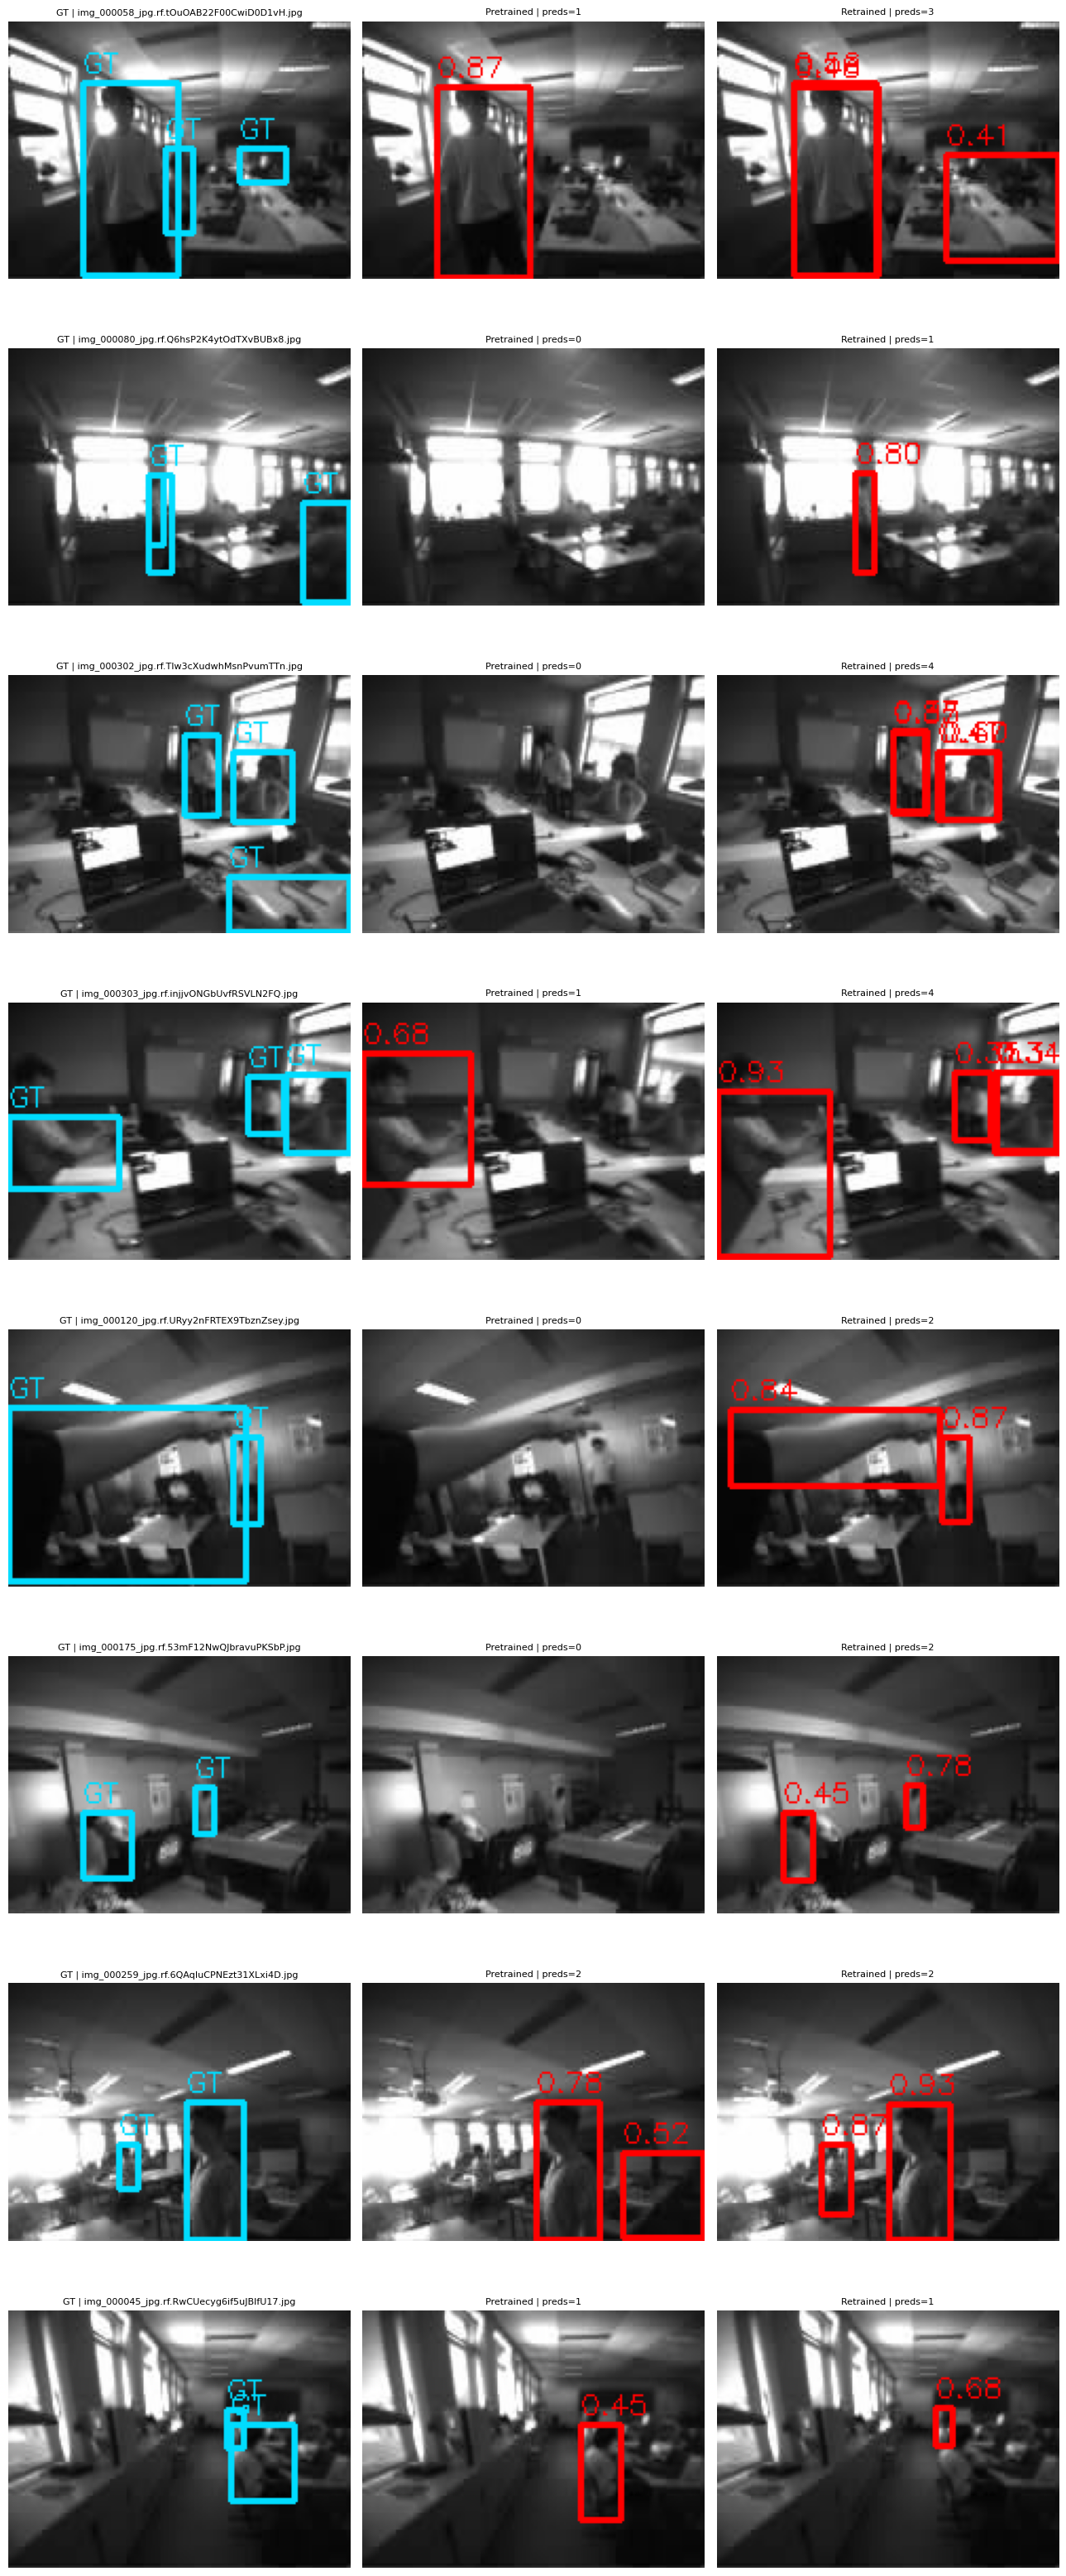

In [13]:
failure_images = [TEST_IMAGE_DIR / name for name in failure_rows["image"].head(8)]

if failure_images:
    fig, axes = plt.subplots(len(failure_images), 3, figsize=(13, 4 * len(failure_images)))
    if len(failure_images) == 1:
        axes = np.array([axes])

    for row_axes, image_path in zip(axes, failure_images):
        gt_boxes, _, _ = image_ground_truth(image_path)
        pre_preds = predict_human_boxes(pretrained_model, image_path, VISUAL_CONF)
        ret_preds = predict_human_boxes(retrained_model, image_path, VISUAL_CONF)

        panels = [
            (draw_boxes(image_path, gt_boxes=gt_boxes), f"GT | {image_path.name}"),
            (draw_boxes(image_path, pred_boxes=pre_preds), f"Pretrained | preds={len(pre_preds)}"),
            (draw_boxes(image_path, pred_boxes=ret_preds), f"Retrained | preds={len(ret_preds)}"),
        ]

        for ax, (image, title) in zip(row_axes, panels):
            ax.imshow(image)
            ax.set_title(title, fontsize=8)
            ax.axis("off")

    plt.tight_layout()
else:
    print("No retrained-model failures at VISUAL_CONF.")


## 10. Save Comparison Tables

This saves the metric tables next to the notebook so you can include them in reports or compare future runs.

In [14]:
COMPARE_DIR = PROJECT_ROOT / "runs" / "yolo26" / "model_comparison"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

official_df.to_csv(COMPARE_DIR / "official_ultralytics_metrics.csv", index=False)
threshold_df.to_csv(COMPARE_DIR / "threshold_metrics.csv", index=False)
per_image_df.to_csv(COMPARE_DIR / "per_image_metrics.csv", index=False)

print("Saved comparison tables to:", COMPARE_DIR)


Saved comparison tables to: C:\Users\Hecos\Documents\sem\industry\vslam\code\detection_model\runs\yolo26\model_comparison
